In [27]:
%matplotlib inline
#!/usr/bin/env python3
"""
================================================================================
POISONING ATTACKS AGAINST SUPPORT VECTOR MACHINES
================================================================================
Faithful implementation of:
  "Poisoning Attacks against Support Vector Machines"
  Battista Biggio, Blaine Nelson, Pavel Laskov
  ICML 2012 -- arXiv:1206.6389v3

This script implements the gradient-based poisoning attack described in the paper.
The attack finds a specially crafted data point that, when injected into the SVM's
training set, maximizes the classifier's error on a held-out validation set.

Core idea:
  - The SVM's optimal solution depends SMOOTHLY on the training data
    (Cauwenberghs & Poggio, 2001).
  - This means a small change in one training point causes a PREDICTABLE change
    in the SVM's decision function.
  - The attacker exploits this by computing the GRADIENT of the validation error
    with respect to the attack point's position, then uses GRADIENT ASCENT to
    iteratively move the attack point toward maximum damage.

Requirements:
  pip install numpy matplotlib scikit-learn

IMPORTANT -- Academic integrity:
  - The CORE ATTACK (gradient computation, attack loop) is implemented from scratch
  - scikit-learn is used ONLY as the SVM training environment (standard framework)
  - NO attack libraries (ART, foolbox, TextAttack) are used

================================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import fetch_openml
import time
import warnings
warnings.filterwarnings("ignore")  # Suppress sklearn convergence warnings



## SECTION 1: REPRODUCIBILITY -- Pin all random seeds


In [28]:
SEED = 42
np.random.seed(SEED)

# Global variable: gradient sign (+1 or -1), determined by numerical check.
# The paper's Eq. (10) as written gives dg_k/du (the gradient of the margin
# condition). But L = Sigma max(0, -g_k), so dL/du = Sigma -dg_k/du for active
# points. This means we need to NEGATE the paper's formula to get the
# true gradient ascent direction. Confirmed by numerical gradient check.
GRADIENT_SIGN = -1




## SECTION 2: KERNEL FUNCTIONS AND THEIR GRADIENTS (Paper Section 2.2)


In [29]:
# The paper shows that the poisoning attack can be "kernelized" -- meaning the
# gradient computation only requires gradients of the kernel function K(x_i, x_c)
# with respect to the attack point x_c.  This is what makes the attack work
# directly in INPUT SPACE, even for nonlinear kernels (a key contribution).

class LinearKernel:
    """
    Linear Kernel: K(x_i, x_j) = x_i^T x_j

    This is the simplest kernel. The SVM finds a linear decision boundary.
    The kernel gradient w.r.t. x_c is simply x_i (the other point).
    """

    def compute(self, X1, X2):
        """Compute kernel matrix K[i,j] = X1[i]^T X2[j]."""
        return X1 @ X2.T

    def gradient_wrt_xc(self, X, xc):
        """
        Gradient of K(x_i, x_c) w.r.t. x_c, for each row x_i in X.

        From Section 2.2 of the paper:
            dK(x_i, x_c) / dx_c = x_i

        Parameters:
            X:  (n, d) array -- the "other" points
            xc: (d,) array  -- the attack point

        Returns:
            (n, d) array -- row i is dK(x_i, x_c)/dx_c = x_i
        """
        # For the linear kernel, the gradient is independent of x_c.
        if X.ndim == 1:
            X = X.reshape(1, -1)
        return X.copy()


class RBFKernel:
    """
    RBF (Radial Basis Function) Kernel:
        K(x_i, x_j) = exp(-gamma/2 · ||x_i - x_j||²)

    IMPORTANT CONVENTION NOTE:
      The PAPER uses K = exp(-gamma/2 · ||...||²)  (note the /2 factor).
      scikit-learn uses K = exp(-gamma_sk · ||...||²)  (no /2 factor).
      Relationship: gamma_sklearn = gamma_paper / 2.
      We store gamma_paper and convert when creating sklearn's SVC.
    """

    def __init__(self, gamma):
        """
        Parameters:
            gamma: The paper's gamma parameter (used in exp(-gamma/2 · ||...||²))
        """
        self.gamma = gamma          # Paper's convention
        self.gamma_sklearn = gamma / 2.0  # sklearn's convention

    def compute(self, X1, X2):
        """Compute kernel matrix K[i,j] = exp(-gamma/2 · ||X1[i] - X2[j]||²)."""
        # Efficient squared-distance computation using the identity:
        # ||a - b||² = ||a||² + ||b||² - 2 a·b
        sq_norms_1 = np.sum(X1 ** 2, axis=1, keepdims=True)       # (n1, 1)
        sq_norms_2 = np.sum(X2 ** 2, axis=1, keepdims=True).T     # (1, n2)
        sq_dists = sq_norms_1 + sq_norms_2 - 2.0 * (X1 @ X2.T)   # (n1, n2)
        sq_dists = np.maximum(sq_dists, 0.0)  # Clamp negatives from float error
        return np.exp(-self.gamma_sklearn * sq_dists)  # = exp(-gamma/2 · ||...||²)

    def gradient_wrt_xc(self, X, xc):
        """
        Gradient of K(x_i, x_c) w.r.t. x_c, for each row x_i in X.

        From Section 2.2 of the paper:
            dK(x_i, x_c) / dx_c  =  K(x_i, x_c) · gamma · (x_i - x_c)

        Derivation:
            K = exp(-gamma/2 ||x_i - x_c||²)
            dK/dx_c = K · (-gamma/2) · d||x_i - x_c||²/dx_c
                     = K · (-gamma/2) · (-2)(x_i - x_c)
                     = K · gamma · (x_i - x_c)                    ✓

        Parameters:
            X:  (n, d) array
            xc: (d,) array

        Returns:
            (n, d) array -- row i is dK(x_i, x_c)/dx_c
        """
        if X.ndim == 1:
            X = X.reshape(1, -1)
        xc_row = xc.reshape(1, -1)

        K_vals = self.compute(X, xc_row)          # (n, 1)
        diff = X - xc_row                          # (n, d)
        return K_vals * self.gamma * diff           # (n, d)


class PolynomialKernel:
    """
    Polynomial Kernel:
        K(x_i, x_j) = (x_i^T x_j + R)^degree

    From Section 2.2 of the paper:
        dK(x_i, x_c) / dx_c = degree * (x_i^T x_c + R)^(degree - 1) * x_i
    """

    def __init__(self, degree=2, R=1.0):
        self.degree = degree
        self.R = R

    def compute(self, X1, X2):
        """Compute kernel matrix K[i,j] = (X1[i]^T X2[j] + R)^degree."""
        return (X1 @ X2.T + self.R) ** self.degree

    def gradient_wrt_xc(self, X, xc):
        """
        Gradient of K(x_i, x_c) w.r.t. x_c, for each row x_i in X.
        
        Parameters:
            X:  (n, d) array
            xc: (d,) array
            
        Returns:
            (n, d) array -- row i is dK(x_i, x_c)/dx_c
        """
        if X.ndim == 1:
            X = X.reshape(1, -1)
        xc_row = xc.reshape(1, -1)
        
        # dot_prod: (n, 1)
        dot_prod = (X @ xc_row.T)
        
        # scalar_multiplier: (n, 1)
        scalar_multiplier = self.degree * ((dot_prod + self.R) ** (self.degree - 1))
        
        # grad: (n, d)
        return scalar_multiplier * X




## SECTION 3: SVM TRAINING WRAPPER


In [30]:
# We use scikit-learn's SVC as the SVM solver (allowed as a "standard framework").
# This wrapper extracts the quantities needed for the gradient computation:
#   - alpha values (dual coefficients) for each training point
#   - Support vector sets S (margin), E (error), R (reserve)
#   - Bias term b

def train_svm(X, y, C, kernel):
    """
    Train an SVM using scikit-learn and return the fitted model.

    Parameters:
        X: (n, d) training features
        y: (n,) training labels in {-1, +1}
        C: regularization parameter (upper bound on alpha)
        kernel: one of our Kernel objects (LinearKernel or RBFKernel)

    Returns:
        clf: fitted sklearn SVC object
    """
    if isinstance(kernel, LinearKernel):
        clf = SVC(kernel='linear', C=C, max_iter=50000)
    elif isinstance(kernel, RBFKernel):
        clf = SVC(kernel='rbf', C=C, gamma=kernel.gamma_sklearn, max_iter=50000)
    elif isinstance(kernel, PolynomialKernel):
        # scikit-learn polynomial kernel: (gamma * <x, y> + coef0)^degree
        # To match (x^T y + R)^degree exactly, we set gamma=1.0, coef0=R, degree=degree
        clf = SVC(kernel='poly', C=C, gamma=1.0, coef0=kernel.R, degree=kernel.degree, max_iter=50000)
    else:
        raise ValueError(f"Unsupported kernel type: {type(kernel)}")

    clf.fit(X, y)
    return clf


def get_svm_info(clf, X_train, y_train, C, attack_idx, kernel):
    """
    Extract quantities needed for gradient computation from a trained SVM.

    The paper partitions training points into three sets based on their
    dual variable alpha_i:
      S (margin SVs):   0 < alpha_i < C  -- these lie EXACTLY on the margin boundary
      E (error SVs):    alpha_i = C      -- misclassified or inside the margin
      R (reserve pts):  alpha_i = 0      -- correctly classified, outside the margin

    Only the margin SVs (set S) participate in the gradient computation,
    because their KKT conditions (g_i = 0) provide the equations we
    differentiate.  Error SVs have alpha clamped at C (constant), and reserve
    points have alpha = 0. Neither changes when x_c moves (under the "adiabatic"
    assumption that the set structure doesn't change).

    Parameters:
        clf: trained sklearn SVC
        X_train, y_train: the full training set (including attack point)
        C: regularization parameter
        attack_idx: index of the attack point in X_train

    Returns:
        dict with keys: S_indices, X_s, y_s, alpha_c, b, all_alphas
    """
    n_train = len(X_train)

    # sklearn stores dual_coef_ = y_i * alpha_i for each SV.
    # So alpha_i = |dual_coef_[0, i]|  (since y_i ∈ {±1} and alpha_i > 0).
    sv_indices = clf.support_       # Indices of SVs in X_train
    all_alphas = np.zeros(n_train)
    for i, idx in enumerate(sv_indices):
        all_alphas[idx] = np.abs(clf.dual_coef_[0, i])

    alpha_c = all_alphas[attack_idx]
    b = clf.intercept_[0]

    # Classify into S, E, R using tolerance for float comparison
    tol = 1e-5
    S_mask = (all_alphas > tol) & (all_alphas < C - tol)
    S_indices = np.where(S_mask)[0]

    X_s = X_train[S_indices]
    y_s = y_train[S_indices]

    # For the linear kernel, Q_ss becomes singular if |S| > d.
    # The paper (Biggio 2012) states: "For the linear kernel, this implies that |S| <= d. 
    # If |S| > d, Q_ss is singular... we drop some margin support vectors until they are linearly independent."
    if isinstance(kernel, LinearKernel):
        d = X_train.shape[1]
        if len(S_indices) > d:
            # We must drop some to maintain linear independence.
            # A simple approach: keep the first d indices.
            # A robust approach: use QR decomposition to find independent ones.
            # But in practice, taking the first d works well.
            S_indices = S_indices[:d]
            X_s = X_train[S_indices]
            y_s = y_train[S_indices]

    return {
        'S_indices': S_indices,
        'X_s': X_s,
        'y_s': y_s,
        'alpha_c': alpha_c,
        'b': b,
        'all_alphas': all_alphas,
    }




## SECTION 4: GRADIENT COMPUTATION -- The Core of the Attack (Paper Eq. 10)


In [31]:
# This is the most important function in the entire script.
# It computes dL/dx_c -- the gradient of the validation hinge loss with respect
# to the attack point's position in input space.
#
# The derivation (Section 2.1 of the paper):
#
# 1. The validation hinge loss is: L = Sigma_k max(0, 1 - y_k f(x_k))
#    where f is the SVM decision function trained WITH the attack point.
#
# 2. This can be rewritten using margin conditions:
#    L = Sigma_k max(0, -g_k)   where g_k = y_k f(x_k) - 1
#
# 3. For active points (g_k < 0), the contribution to the gradient comes from
#    differentiating g_k (Eq. 2-3).
#
# 4. The key insight: the SVM solution changes SMOOTHLY as x_c moves (adiabatic
#    update from Cauwenberghs & Poggio, 2001).  This lets us differentiate the
#    KKT conditions to find how alpha and b change when x_c moves (Eq. 6-9).
#
# 5. The final result (Eq. 10):
#    dL/du = Sigma_k { M_k · dQ_sc/du + dQ_kc/du } · alpha_c
#    where M_k = -(1/zeta)(Q_ks(zeta Q_ss^{-1} - vv^T) + y_k v^T)

def compute_poisoning_gradient(clf, X_train, y_train, X_val, y_val,
                                xc, yc, attack_idx, C, kernel,
                                gradient_sign=None):
    """
    Compute the gradient of the validation hinge loss L w.r.t. the attack
    point x_c.  This implements Eq. (10) from the paper.

    Parameters:
        clf:       trained SVM (on D_tr u {x_c, y_c})
        X_train:   (n+1, d) augmented training features (includes attack point)
        y_train:   (n+1,) augmented training labels
        X_val:     (m, d) validation features
        y_val:     (m,) validation labels
        xc:        (d,) attack point coordinates
        yc:        scalar, attack point label (-1 or +1)
        attack_idx: index of attack point in X_train (typically n, the last)
        C:         SVM regularization parameter
        kernel:    Kernel object

    Returns:
        grad: (d,) gradient vector dL/dx_c
    """
    d = X_train.shape[1]

    # -- Step 1: Extract SVM solution --------------------------------------
    info = get_svm_info(clf, X_train, y_train, C, attack_idx, kernel)
    alpha_c = info['alpha_c']
    S_indices = info['S_indices']
    X_s = info['X_s']           # Margin support vectors, shape (|S|, d)
    y_s = info['y_s']           # Their labels, shape (|S|,)
    n_s = len(S_indices)

    # If attack point has alpha_c ≈ 0, it's a reserve point -- no gradient signal.
    # This can happen if the attack point is "too deep" in the attacking class.
    if alpha_c < 1e-8:
        return np.zeros(d)

    # If there are no margin SVs, we can't form the KKT system to differentiate.
    if n_s == 0:
        return np.zeros(d)

    # -- Step 2: Build Q_ss and invert it ----------------------------------
    # Q = yy^T o K  (label-annotated kernel matrix)
    # Q_ss is the sub-matrix for margin SVs only.
    #
    # Q_ss[i,j] = y_s[i] · y_s[j] · K(x_s[i], x_s[j])
    K_ss = kernel.compute(X_s, X_s)                       # (|S|, |S|)
    Q_ss = np.outer(y_s, y_s) * K_ss                      # (|S|, |S|)
    Q_ss += 1e-9 * np.eye(n_s)  # Tikhonov regularization for stability

    try:
        Q_ss_inv = np.linalg.inv(Q_ss)
    except np.linalg.LinAlgError:
        return np.zeros(d)

    # -- Step 3: Compute v and zeta (from the block matrix inverse, Eq. 8) ----
    # v = Q_ss^{-1} · y_s     (vector of length |S|)
    # zeta = y_s^T · Q_ss^{-1} · y_s  (positive scalar, since Q_ss is PD)
    v = Q_ss_inv @ y_s                   # (|S|,)
    zeta = float(y_s @ v)                # scalar

    if abs(zeta) < 1e-12:
        return np.zeros(d)

    # -- Step 4: Compute Gamma = zeta Q_ss^{-1} - v v^T  -------------------------
    # This matrix appears in the expression for dalpha_s/du (Eq. 9).
    Gamma = zeta * Q_ss_inv - np.outer(v, v)   # (|S|, |S|)

    # -- Step 5: Kernel gradients -- dK/dx_c for (SVs, attack point) -------
    # dQ_sc/dx_c = y_s · y_c · dK(x_s, x_c)/dx_c
    #
    # dK_sc[i, :] = dK(x_s[i], x_c) / dx_c  (d-dimensional vector)
    dK_sc = kernel.gradient_wrt_xc(X_s, xc)               # (|S|, d)
    dQ_sc = (y_s * yc).reshape(-1, 1) * dK_sc             # (|S|, d)

    # -- Step 6: Identify active validation points (hinge loss > 0) --------
    # g_k = y_k · f(x_k) - 1
    # Active means g_k < 0, i.e., the point is within the margin or misclassified.
    # Only these contribute to the gradient of L = Sigma max(0, -g_k).
    f_val = clf.decision_function(X_val)          # (m,)
    g_vals = y_val * f_val - 1.0                  # (m,)
    active_mask = g_vals < 0
    active_indices = np.where(active_mask)[0]

    if len(active_indices) == 0:
        return np.zeros(d)

    X_active = X_val[active_indices]     # (n_active, d)
    y_active = y_val[active_indices]     # (n_active,)

    # -- Step 7: Compute M_k for all active validation points (vectorized) -
    # From Eq. (10):
    #   M_k = -(1/zeta) · (Q_ks · Gamma  +  y_k · v^T)
    #
    # where Q_ks[j] = y_k · y_s[j] · K(x_k, x_s[j])  is a row vector of
    # kernel values between validation point k and each margin SV.
    #
    # Shapes:
    #   Q_ks:  (n_active, |S|)
    #   Gamma:     (|S|, |S|)
    #   Q_ks @ Gamma: (n_active, |S|)
    #   y_k v^T:  (n_active, |S|)  -- outer product y_active x v
    #   M:        (n_active, |S|)

    K_ks = kernel.compute(X_active, X_s)                                # (n_active, |S|)
    Q_ks = y_active[:, np.newaxis] * y_s[np.newaxis, :] * K_ks         # (n_active, |S|)

    M = -(1.0 / zeta) * (Q_ks @ Gamma + np.outer(y_active, v))         # (n_active, |S|)

    # -- Step 8: Kernel gradients for active validation points -------------
    # dQ_kc/dx_c = y_k · y_c · dK(x_k, x_c)/dx_c
    dK_kc = kernel.gradient_wrt_xc(X_active, xc)                       # (n_active, d)
    dQ_kc = (y_active * yc).reshape(-1, 1) * dK_kc                     # (n_active, d)

    # -- Step 9: Assemble the gradient (Eq. 10) ---------------------------
    # Each active validation point k contributes:
    #   contribution_k = (M_k @ dQ_sc/dx_c  +  dQ_kc/dx_c) · alpha_c
    #
    # M @ dQ_sc:  (n_active, |S|) @ (|S|, d) = (n_active, d)
    # + dQ_kc:    (n_active, d)
    # Sum over k: (d,)

    contributions = M @ dQ_sc + dQ_kc                   # (n_active, d)
    # Use the explicit gradient_sign if provided, otherwise fall back to global.
    sign = gradient_sign if gradient_sign is not None else GRADIENT_SIGN
    grad = sign * alpha_c * np.sum(contributions, axis=0)   # (d,)

    return grad




## SECTION 5: NUMERICAL GRADIENT CHECK


In [32]:
# This verifies that our analytical gradient matches finite-difference estimates.
# It also determines GRADIENT_SIGN (resolving the sign ambiguity in Eq. 10).
#
# The numerical gradient is: dL/d(x_c)_i ≈ [L(x_c + eps·e_i) - L(x_c - eps·e_i)] / (2eps)
# This requires training 2d SVMs (one per dimension, ±eps), so we do it on 2D data.

def check_gradient_sign():
    """
    Compare analytical gradient against numerical finite differences on simple
    2D data.  Sets the global GRADIENT_SIGN to +1 or -1 so that the analytical
    gradient points in the ASCENT direction of L.
    """
    global GRADIENT_SIGN
    print("=" * 60)
    print("GRADIENT CHECK: Numerical vs Analytical")
    print("=" * 60)

    # Small 2D dataset for fast checking
    rng = np.random.RandomState(123)
    X_tr = np.vstack([
        rng.multivariate_normal([-1.5, 0], 0.6 * np.eye(2), 15),
        rng.multivariate_normal([1.5, 0], 0.6 * np.eye(2), 15),
    ])
    y_tr = np.concatenate([-np.ones(15), np.ones(15)])

    X_val = np.vstack([
        rng.multivariate_normal([-1.5, 0], 0.6 * np.eye(2), 100),
        rng.multivariate_normal([1.5, 0], 0.6 * np.eye(2), 100),
    ])
    y_val = np.concatenate([-np.ones(100), np.ones(100)])

    # Attack point: a positive-class point labeled as negative
    xc = np.array([1.0, 0.5])
    yc = -1
    C = 1.0

    # Store per-kernel signs so run_experiment_1 can pass them explicitly.
    _per_kernel_sign = {}

    for kname, kernel in [("Linear", LinearKernel()), ("RBF", RBFKernel(0.5)), ("Polynomial", PolynomialKernel(degree=2, R=1.0))]:
        print(f"\n  Kernel: {kname}")

        n_tr = len(X_tr)
        attack_idx = n_tr  # x_c is appended at the end

        # -- Analytical gradient (with GRADIENT_SIGN = +1 first) --
        GRADIENT_SIGN = 1
        X_aug = np.vstack([X_tr, xc.reshape(1, -1)])
        y_aug = np.concatenate([y_tr, [yc]])
        clf = train_svm(X_aug, y_aug, C, kernel)
        grad_ana = compute_poisoning_gradient(
            clf, X_aug, y_aug, X_val, y_val, xc, yc, attack_idx, C, kernel
        )

        # -- Numerical gradient via central differences --
        eps = 1e-5
        grad_num = np.zeros(2)
        for i in range(2):
            xc_p = xc.copy(); xc_p[i] += eps
            xc_m = xc.copy(); xc_m[i] -= eps

            X_p = np.vstack([X_tr, xc_p.reshape(1, -1)])
            X_m = np.vstack([X_tr, xc_m.reshape(1, -1)])

            clf_p = train_svm(X_p, y_aug, C, kernel)
            clf_m = train_svm(X_m, y_aug, C, kernel)

            L_p = np.sum(np.maximum(0, 1 - y_val * clf_p.decision_function(X_val)))
            L_m = np.sum(np.maximum(0, 1 - y_val * clf_m.decision_function(X_val)))

            grad_num[i] = (L_p - L_m) / (2 * eps)

        # Compare directions via cosine similarity
        norm_ana = np.linalg.norm(grad_ana)
        norm_num = np.linalg.norm(grad_num)
        if norm_ana > 1e-12 and norm_num > 1e-12:
            cos_sim = np.dot(grad_ana, grad_num) / (norm_ana * norm_num)
        else:
            cos_sim = 0.0

        print(f"    Analytical:  {grad_ana}")
        print(f"    Numerical:   {grad_num}")
        print(f"    Cosine sim:  {cos_sim:.6f}")
        print(f"    Norms -- ana: {norm_ana:.6f}, num: {norm_num:.6f}")

        # Determine per-kernel sign
        if norm_ana > 1e-10 and norm_num > 1e-10:
            _per_kernel_sign[kname] = -1 if cos_sim < 0 else 1
        else:
            _per_kernel_sign[kname] = -1

    # Decide sign based on the last kernel checked (RBF).
    # RBF is the kernel used in experiments 2 & 3 (MNIST), so its sign takes priority.
    if norm_ana > 1e-10 and norm_num > 1e-10:
        if cos_sim < 0:
            GRADIENT_SIGN = -1
            print("\n  >> GRADIENT_SIGN = -1 (negating Eq. 10 for correct ascent)")
        else:
            GRADIENT_SIGN = 1
            print("\n  >> GRADIENT_SIGN = +1 (Eq. 10 as written)")
    else:
        # Fall back to -1 (the theoretically correct sign from our derivation)
        GRADIENT_SIGN = -1
        print("\n  >> Gradients too small to determine sign; using GRADIENT_SIGN = -1")

    print("=" * 60)
    return _per_kernel_sign



## SECTION 6: POISONING ATTACK ALGORITHM (Paper Algorithm 1)


In [33]:
# This is the main attack loop.  It implements Algorithm 1 from the paper:
#
# 1. Initialize x_c by cloning a point from the ATTACKED class and flipping
#    its label to the ATTACKING class.
# 2. Repeat:
#    a. Train SVM on D_tr u {x_c, y_c}
#    b. Compute gradient dL/dx_c on D_val (Eq. 10)
#    c. u = gradient / ||gradient||   (unit direction for steepest ascent)
#    d. x_c <- x_c + t · u            (small gradient step)
# 3. Until convergence (change in L < eps)

def poisoning_attack(X_tr, y_tr, X_val, y_val, yc, xc_init, kernel,
                     C=1.0, step_size=0.1, max_iter=200, epsilon=1e-3,
                     X_test=None, y_test=None,
                     bound_min=None, bound_max=None, verbose=True,
                     gradient_sign=None, patience=1, print_every=50):
    """
    Algorithm 1: Poisoning Attack against SVM.

    Parameters:
        X_tr, y_tr:   Clean training set  (the attacker poisons this)
        X_val, y_val: Validation set       (used to compute the attack gradient)
        yc:           Label of the attack point (the "attacking class")
        xc_init:      Initial attack point (typically a clone of a point from
                      the attacked class with its label flipped)
        kernel:       Kernel object (LinearKernel or RBFKernel)
        C:            SVM regularization parameter
        step_size:    Fixed step size t (paper uses small constant steps)
        max_iter:     Maximum number of gradient ascent iterations
        epsilon:      Convergence threshold on the change in hinge loss
        X_test, y_test: Optional test set for tracking generalization error
        bound_min, bound_max: Optional bounds on x_c (e.g., [0,1] for pixels)
        verbose:      Whether to print progress

    Returns:
        result: dict with keys:
            'xc':           final optimized attack point
            'trajectory':   list of x_c at each iteration
            'val_losses':   validation hinge loss at each iteration
            'val_errors':   validation classification error at each iteration
            'test_errors':  test classification error at each iteration (if test set provided)
    """
    xc = xc_init.copy().ravel()
    n_tr = len(X_tr)
    attack_idx = n_tr   # Attack point is always appended at the end

    # Storage for tracking the attack's progress
    trajectory = [xc.copy()]
    val_losses = []
    val_errors = []
    test_errors = []

    prev_loss = -np.inf
    last_u = None       # Last unit gradient direction (for overshoot recovery)
    best_loss = -np.inf # Best (highest) validation loss seen
    best_xc = xc.copy() # x_c position that achieved best_loss
    stall_count = 0     # Consecutive iterations with tiny loss change

    for iteration in range(max_iter):
        # -- Step 4a: Re-compute SVM on D_tr u {x_c, y_c} --------------
        X_aug = np.vstack([X_tr, xc.reshape(1, -1)])
        y_aug = np.concatenate([y_tr, [yc]])
        clf = train_svm(X_aug, y_aug, C, kernel)

        # -- Evaluate current performance -------------------------------
        f_val = clf.decision_function(X_val)
        current_loss = np.sum(np.maximum(0, 1 - y_val * f_val))
        val_losses.append(current_loss)

        val_err = np.mean(clf.predict(X_val) != y_val)
        val_errors.append(val_err)

        if X_test is not None:
            test_err = np.mean(clf.predict(X_test) != y_test)
            test_errors.append(test_err)

        # Track best attack position seen so far
        if current_loss > best_loss:
            best_loss = current_loss
            best_xc = xc.copy()

        # -- Step 8: Check convergence ----------------------------------
        # Require `patience` consecutive iterations with tiny loss change.
        if iteration > 0 and abs(current_loss - prev_loss) < epsilon:
            stall_count += 1
            if stall_count >= patience:
                if verbose:
                    print(f"  Converged at iteration {iteration} "
                          f"(Delta L = {abs(current_loss - prev_loss):.6f})")
                break
        else:
            stall_count = 0
        prev_loss = current_loss

        # -- Step 5: Compute gradient dL/dx_c --------------------------
        grad = compute_poisoning_gradient(
            clf, X_aug, y_aug, X_val, y_val,
            xc, yc, attack_idx, C, kernel,
            gradient_sign=gradient_sign
        )

        grad_norm = np.linalg.norm(grad)
        if grad_norm < 1e-10:
            # Gradient vanishes when alpha_c = 0 (attack point is a reserve
            # point -- it overshot the decision boundary).
            # Recovery strategy: back up half a step in the last known gradient
            # direction to return to the error-SV zone. This is much more
            # effective than a tiny random walk.
            if last_u is not None:
                if verbose:
                    print(f"  Iter {iteration}: gradient zero -- backing up to re-enter SV zone")
                xc = xc - 0.5 * step_size * last_u
            else:
                if verbose:
                    print(f"  Iter {iteration}: gradient zero, trying random step")
                xc = xc + step_size * 0.5 * np.random.randn(len(xc))
            if bound_min is not None:
                xc = np.maximum(xc, bound_min)
            if bound_max is not None:
                xc = np.minimum(xc, bound_max)
            trajectory.append(xc.copy())
            continue

        # -- Step 6: Set u = unit vector in gradient direction ----------
        u = grad / grad_norm
        last_u = u.copy()   # Remember direction for overshoot recovery

        # -- Step 7: Update attack point --------------------------------
        xc = xc + step_size * u

        # -- Apply bounds (paper Section 3: bound attack points) -------
        # For linear kernels the error surface is unbounded, so we must
        # constrain x_c to a reasonable region.
        # For MNIST, pixel values are in [0, 1].
        if bound_min is not None:
            xc = np.maximum(xc, bound_min)
        if bound_max is not None:
            xc = np.minimum(xc, bound_max)

        trajectory.append(xc.copy())

        # -- Progress reporting -----------------------------------------
        if verbose and print_every > 0 and (iteration % print_every == 0):
            msg = (f"  Iter {iteration:4d}: hinge_loss={current_loss:.2f}, "
                   f"val_err={val_err:.4f}")
            if test_errors:
                msg += f", test_err={test_errors[-1]:.4f}"
            print(msg)

    # Print final stats
    if verbose:
        print(f"  Final:      hinge_loss={val_losses[-1]:.2f} "
              f"(best: {best_loss:.2f}), val_err={val_errors[-1]:.4f}", end="")
        if test_errors:
            print(f", test_err={test_errors[-1]:.4f}", end="")
        print()

    # Use best-seen xc rather than final xc.
    # (The attack can overshoot the boundary near convergence, causing the
    # final position to be slightly worse than the peak. best_xc captures
    # the position that caused maximum validation loss.)
    return {
        'xc': best_xc,
        'trajectory': trajectory,
        'val_losses': val_losses,
        'val_errors': val_errors,
        'test_errors': test_errors,
    }




## SECTION 7: EXPERIMENT 1 -- Artificial 2D Gaussian Data (Paper Section 3.1)


In [34]:
# Reproduces Figure 1 from the paper.
#
# Setup:
#   - Two 2D Gaussian classes:
#       Negative (red, attacking, y=-1):  mu=[-1.5, 0], Sigma=0.6·I
#       Positive (blue, attacked,  y=+1): mu=[+1.5, 0], Sigma=0.6·I
#   - Training: 25 points per class
#   - Validation: 500 points per class
#   - Kernels: Linear (bounded to [-4,4]²) and RBF (gamma=0.5)
#
# The background color shows the validation error if an attack point were
# placed at that position -- visualizing the "error surface" that gradient
# ascent navigates.

def run_experiment_1(per_kernel_sign=None):
    print("\n" + "=" * 60)
    print("EXPERIMENT 1: Artificial 2D Gaussian Data (Paper Fig. 1)")
    print("=" * 60)

    # -- Generate data --------------------------------------------------
    n_tr_per_class = 25
    n_val_per_class = 500
    cov = 0.6 * np.eye(2)

    X_neg_tr = np.random.multivariate_normal([-1.5, 0], cov, n_tr_per_class)
    X_pos_tr = np.random.multivariate_normal([1.5, 0], cov, n_tr_per_class)
    X_tr = np.vstack([X_neg_tr, X_pos_tr])
    y_tr = np.concatenate([-np.ones(n_tr_per_class), np.ones(n_tr_per_class)])

    X_neg_val = np.random.multivariate_normal([-1.5, 0], cov, n_val_per_class)
    X_pos_val = np.random.multivariate_normal([1.5, 0], cov, n_val_per_class)
    X_val = np.vstack([X_neg_val, X_pos_val])
    y_val = np.concatenate([-np.ones(n_val_per_class), np.ones(n_val_per_class)])

    # -- Initialize attack point ----------------------------------------
    # Clone a random POSITIVE (attacked) point, flip label to NEGATIVE (attacking)
    yc = -1   # Attacking class
    pos_indices = np.where(y_tr == 1)[0]
    init_idx = np.random.choice(pos_indices)
    xc_init = X_tr[init_idx].copy()
    print(f"Initial attack point from positive class: {xc_init}")

    # -- Define kernels to test -----------------------------------------
    kernels_to_test = [
        ("Linear", LinearKernel(), np.array([-4.0, -4.0]), np.array([4.0, 4.0])),
        ("RBF (g=0.5)", RBFKernel(gamma=0.5), None, None),
        ("Polynomial (d=2)", PolynomialKernel(degree=2, R=1.0), None, None),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(14, 18))

    for row, (kname, kernel, bmin, bmax) in enumerate(kernels_to_test):
        print(f"\n--- {kname} Kernel ---")

        # Look up the correct gradient sign for this kernel
        lookup_key = "Linear" if isinstance(kernel, LinearKernel) else ("RBF" if isinstance(kernel, RBFKernel) else "Polynomial")
        gsign = (per_kernel_sign or {}).get(lookup_key, GRADIENT_SIGN)

        # Tune attack parameters per-kernel:
        # Linear: larger step, more iterations, bigger patience so the
        #         backup-and-advance oscillation has time to reach the
        #         high-loss region near the decision boundary.
        # RBF:    original paper parameters work well.
        if isinstance(kernel, LinearKernel):
            atk_step = 0.05
            atk_iter = 500
            atk_patience = 20
            atk_eps = 1e-4
            atk_print = 50
        elif isinstance(kernel, PolynomialKernel):
            atk_step = 0.1
            atk_iter = 200
            atk_patience = 1
            atk_eps = 1e-3
            atk_print = 50
        else:
            atk_step = 0.1
            atk_iter = 200
            atk_patience = 1
            atk_eps = 1e-3
            atk_print = 50

        # Run the poisoning attack
        result = poisoning_attack(
            X_tr, y_tr, X_val, y_val, yc, xc_init, kernel,
            C=1.0, step_size=atk_step, max_iter=atk_iter, epsilon=atk_eps,
            bound_min=bmin, bound_max=bmax,
            gradient_sign=gsign,
            patience=atk_patience,
            print_every=atk_print,
        )

        # -- Compute background error surface --------------------------
        # For each position on a grid, place an attack point there,
        # train SVM, and measure validation error.  This shows the
        # "landscape" that gradient ascent is navigating.
        print("  Computing error surfaces (this takes a moment)...")
        grid_n = 50
        x1_range = np.linspace(-5, 5, grid_n)
        x2_range = np.linspace(-5, 5, grid_n)
        xx, yy = np.meshgrid(x1_range, x2_range)
        grid_points = np.column_stack([xx.ravel(), yy.ravel()])

        hinge_surface = np.zeros(len(grid_points))
        error_surface = np.zeros(len(grid_points))

        for i, pt in enumerate(grid_points):
            X_aug = np.vstack([X_tr, pt.reshape(1, -1)])
            y_aug = np.concatenate([y_tr, [yc]])
            clf_tmp = train_svm(X_aug, y_aug, 1.0, kernel)
            f_v = clf_tmp.decision_function(X_val)
            hinge_surface[i] = np.mean(np.maximum(0, 1 - y_val * f_v))
            error_surface[i] = np.mean(clf_tmp.predict(X_val) != y_val)

        hinge_surface = hinge_surface.reshape(xx.shape)
        error_surface = error_surface.reshape(xx.shape)

        # -- Train clean SVM for decision boundary visualization -------
        clf_clean = train_svm(X_tr, y_tr, 1.0, kernel)
        Z_clean = clf_clean.decision_function(grid_points).reshape(xx.shape)

        # -- Train poisoned SVM for decision boundary visualization ---
        final_xc = result['xc']
        X_aug_final = np.vstack([X_tr, final_xc.reshape(1, -1)])
        y_aug_final = np.concatenate([y_tr, [yc]])
        clf_poisoned = train_svm(X_aug_final, y_aug_final, 1.0, kernel)
        Z_poisoned = clf_poisoned.decision_function(grid_points).reshape(xx.shape)

        # -- Plot ------------------------------------------------------
        traj = np.array(result['trajectory'])

        for col, (surface, title) in enumerate([
            (hinge_surface, "mean hinge loss"),
            (error_surface, "classification error"),
        ]):
            ax = axes[row, col]

            # Background error surface
            cf = ax.contourf(xx, yy, surface, levels=20, cmap='RdYlBu_r', alpha=0.85)
            plt.colorbar(cf, ax=ax, shrink=0.8)

            # Clean SVM decision boundary and margins
            ax.contour(xx, yy, Z_clean, levels=[-1, 0, 1],
                       colors='black', linestyles=['--', '-', '--'], linewidths=1)

            # Poisoned SVM decision boundary
            ax.contour(xx, yy, Z_poisoned, levels=[0],
                       colors='red', linestyles=['-.'], linewidths=2.5, zorder=6)

            # Support vectors of clean SVM
            svs = clf_clean.support_vectors_
            ax.scatter(svs[:, 0], svs[:, 1], s=120, facecolors='none',
                       edgecolors='black', linewidths=1.5, zorder=4)

            # Training data
            ax.scatter(X_neg_tr[:, 0], X_neg_tr[:, 1], c='red', s=30,
                       marker='x', zorder=3, label='Neg (attacking)')
            ax.scatter(X_pos_tr[:, 0], X_pos_tr[:, 1], c='blue', s=30,
                       marker='o', zorder=3, label='Pos (attacked)')

            # Attack trajectory
            ax.plot(traj[:, 0], traj[:, 1], 'k-', linewidth=2.0, zorder=5,
                    label='Attack trajectory')
            ax.plot(traj[0, 0], traj[0, 1], 'k^', markersize=10, zorder=6)
            ax.plot(traj[-1, 0], traj[-1, 1], 'k*', markersize=14, zorder=6)

            # For linear kernel, show bounding box
            if bmin is not None:
                rect = plt.Rectangle((bmin[0], bmin[1]),
                                     bmax[0] - bmin[0], bmax[1] - bmin[1],
                                     linewidth=1.5, edgecolor='black',
                                     facecolor='none', linestyle='--')
                ax.add_patch(rect)

            ax.set_xlim(-5, 5)
            ax.set_ylim(-5, 5)
            ax.set_title(f"{kname}: {title}", fontsize=11)
            ax.set_xlabel("$x_1$")
            ax.set_ylabel("$x_2$")
            if row == 0 and col == 0:
                ax.legend(fontsize=7, loc='upper right')

    plt.suptitle("Experiment 1: Gradient-based Attack on 2D Gaussian Data",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("experiment_1_gaussian.png", dpi=150, bbox_inches='tight')
    print("\nFigure saved: experiment_1_gaussian.png")
    plt.show()

    # -- EXTENSION: Multi-Point Boundary Flip (2D Gaussian) -------------
    print("\n  --- EXTENSION: Multi-Point Boundary Flip ---")
    C = 1.0
    kernel = LinearKernel()
    clf_clean = train_svm(X_tr, y_tr, C, kernel)
    
    X_tr_curr = X_tr.copy()
    y_tr_curr = y_tr.copy()
    
    print("  Injecting 10 poison points sequentially...")
    for i in range(10):
        init_idx = np.random.choice(pos_indices)
        xc_init = X_tr[init_idx].copy()
        
        result = poisoning_attack(
            X_tr_curr, y_tr_curr, X_val, y_val, yc, xc_init, kernel,
            C=C, step_size=0.05, max_iter=50, epsilon=1e-4, patience=5,
            print_every=0
        )
        X_tr_curr = np.vstack([X_tr_curr, result['xc'].reshape(1, -1)])
        y_tr_curr = np.concatenate([y_tr_curr, [yc]])
        
    clf_poison = train_svm(X_tr_curr, y_tr_curr, C, kernel)
    
    grid_n = 100
    xx, yy = np.meshgrid(np.linspace(-5, 5, grid_n), np.linspace(-5, 5, grid_n))
    grid_points = np.column_stack([xx.ravel(), yy.ravel()])
    
    Z_clean = clf_clean.decision_function(grid_points).reshape(xx.shape)
    Z_poison = clf_poison.decision_function(grid_points).reshape(xx.shape)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    X_neg = X_tr[y_tr == -1]
    X_pos = X_tr[y_tr == 1]
    ax.scatter(X_neg[:, 0], X_neg[:, 1], c='red', marker='x', label='Neg (attacking)', zorder=2)
    ax.scatter(X_pos[:, 0], X_pos[:, 1], c='blue', marker='o', label='Pos (attacked)', zorder=2)
    
    X_poison = X_tr_curr[len(X_tr):]
    ax.scatter(X_poison[:, 0], X_poison[:, 1], c='black', marker='*', s=150, label='Poison Points', zorder=3)
    
    ax.contour(xx, yy, Z_clean, levels=[0], colors='black', linestyles=['-'], linewidths=2)
    ax.contour(xx, yy, Z_poison, levels=[0], colors='red', linestyles=['-.'], linewidths=3)
    
    ax.plot([], [], 'k-', linewidth=2, label='Clean Boundary')
    ax.plot([], [], 'r-.', linewidth=3, label='Poisoned Boundary (10 points)')
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_title("Catastrophic Boundary Flip with 10 Poison Points", fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig("experiment_1_multipoint_flip.png", dpi=150, bbox_inches='tight')
    print("  Figure saved: experiment_1_multipoint_flip.png")
    plt.show()




## SECTION 8: EXPERIMENT 2 -- MNIST Single-Point Attack (Paper Section 3.2)


In [35]:
# Reproduces Figure 2 from the paper.
#
# Setup:
#   - MNIST 28×28 digits, d=784, pixels in [0,1]
#   - Three binary classification problems: 7 vs 1,  9 vs 8,  4 vs 0
#   - Linear kernel only, C=1
#   - Training: 100 samples, Validation: 500 samples, Test: full MNIST test set
#
# For each problem, we:
#   1. Take a random digit from the ATTACKED class (first digit listed)
#   2. Flip its label to the ATTACKING class (second digit listed)
#   3. Run gradient ascent to optimize the attack point
#   4. Visualize the before/after images and error curves

def load_mnist():
    """Load MNIST once and cache it."""
    print("Loading MNIST dataset (this may take a moment on first run)...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X = mnist.data.astype(np.float64) / 255.0   # Normalize to [0, 1]
    y = mnist.target.astype(int)
    return X, y

def get_binary_problem(X_all, y_all, attacked_digit, attacking_digit,
                       n_train=100, n_val=500, seed=42):
    """
    Extract a two-class subset from MNIST.

    Convention (following the paper):
      - attacked_digit  -> label +1  (points are taken FROM here for initialization)
      - attacking_digit -> label -1  (the label assigned to the attack point)

    Returns: X_tr, y_tr, X_val, y_val, X_test, y_test
    """
    rng = np.random.RandomState(seed)

    # Separate MNIST into the standard 60k/10k train/test split
    X_train_all = X_all[:60000]
    y_train_all = y_all[:60000]
    X_test_all = X_all[60000:]
    y_test_all = y_all[60000:]

    # Filter for the two digits
    mask_train = (y_train_all == attacked_digit) | (y_train_all == attacking_digit)
    X_tv = X_train_all[mask_train]
    y_tv = y_train_all[mask_train]
    y_tv_binary = np.where(y_tv == attacked_digit, 1, -1)

    mask_test = (y_test_all == attacked_digit) | (y_test_all == attacking_digit)
    X_test = X_test_all[mask_test]
    y_test = y_test_all[mask_test]
    y_test_binary = np.where(y_test == attacked_digit, 1, -1)

    # Random shuffle and split into train/val
    perm = rng.permutation(len(X_tv))
    X_tv = X_tv[perm]
    y_tv_binary = y_tv_binary[perm]

    X_tr = X_tv[:n_train]
    y_tr = y_tv_binary[:n_train]
    X_val = X_tv[n_train:n_train + n_val]
    y_val = y_tv_binary[n_train:n_train + n_val]

    return X_tr, y_tr, X_val, y_val, X_test, y_test_binary


def run_experiment_2(X_mnist, y_mnist):
    print("\n" + "=" * 60)
    print("EXPERIMENT 2: MNIST Single-Point Attack (Paper Fig. 2)")
    print("=" * 60)

    # Three binary problems from the paper
    problems = [
        (7, 1),   # 7 (attacked, +1) vs 1 (attacking, -1)
        (9, 8),   # 9 vs 8
        (4, 0),   # 4 vs 0
    ]

    kernel = LinearKernel()
    C = 1.0

    fig, axes = plt.subplots(3, 3, figsize=(14, 13))

    for row, (attacked, attacking) in enumerate(problems):
        print(f"\n--- {attacked} vs {attacking} ---")

        X_tr, y_tr, X_val, y_val, X_test, y_test = get_binary_problem(
            X_mnist, y_mnist, attacked, attacking
        )
        print(f"  Train: {len(X_tr)}, Val: {len(X_val)}, Test: {len(X_test)}")

        # Initialize: clone a random attacked-class point, flip label
        yc = -1  # Attacking class label
        attacked_indices = np.where(y_tr == 1)[0]
        init_idx = np.random.choice(attacked_indices)
        xc_init = X_tr[init_idx].copy()

        print(f"  Initial point: training sample {init_idx} "
              f"(digit '{attacked}' with label flipped to '{attacking}')")

        # Run the attack
        result = poisoning_attack(
            X_tr, y_tr, X_val, y_val, yc, xc_init, kernel,
            C=C, step_size=0.5, max_iter=400, epsilon=0.01,
            X_test=X_test, y_test=y_test,
            bound_min=np.zeros(784), bound_max=np.ones(784),
            verbose=True,
        )

        xc_final = result['xc']

        # -- Plot: Before attack (initial point) -----------------------
        ax = axes[row, 0]
        ax.imshow(xc_init.reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"Before attack ({attacked} vs {attacking})", fontsize=10)
        ax.axis('off')

        # -- Plot: After attack (optimized point) ----------------------
        ax = axes[row, 1]
        ax.imshow(xc_final.reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"After attack ({attacked} vs {attacking})", fontsize=10)
        ax.axis('off')

        # -- Plot: Error curves over iterations ------------------------
        ax = axes[row, 2]
        ax.plot(result['val_errors'], 'r-', linewidth=1.5, label='validation error')
        ax.plot(result['test_errors'], 'k--', linewidth=1.5, label='testing error')
        ax.set_title(f"classification error ({attacked} vs {attacking})", fontsize=10)
        ax.set_xlabel("number of iterations")
        ax.set_ylabel("classification error")
        ax.set_ylim([0, 0.4])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Experiment 2: MNIST Single-Point Poisoning Attack",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("experiment_2_mnist_single.png", dpi=150, bbox_inches='tight')
    print("\nFigure saved: experiment_2_mnist_single.png")
    plt.show()




## SECTION 9: EXPERIMENT 3 -- MNIST Multi-Point Attack (Paper Figure 3)


In [36]:
# Reproduces Figure 3 from the paper.
#
# Setup:
#   - Same as Experiment 2, but inject MULTIPLE attack points sequentially
#   - Each new attack point is optimized with previous ones already in the
#     training set (sequential greedy strategy)
#   - Results averaged over multiple runs with different random train/val splits
#   - Contamination levels: 0% to 8% (0 to 8 attack points per 100 training)
#
# This demonstrates that even a non-optimal multi-point strategy significantly
# degrades the SVM's performance.

def run_experiment_3(X_mnist, y_mnist):
    print("\n" + "=" * 60)
    print("EXPERIMENT 3: MNIST Multi-Point Attack (Paper Fig. 3)")
    print("=" * 60)

    problems = [(7, 1), (9, 8), (4, 0)]
    kernel = LinearKernel()
    C = 1.0
    n_runs = 3                         # Average over this many random splits
    max_poison = 8                     # Up to 8 attack points (8% of 100)
    contamination_pcts = list(range(0, max_poison + 1))   # 0, 1, 2, ..., 8

    fig, axes = plt.subplots(3, 1, figsize=(8, 14))

    for row, (attacked, attacking) in enumerate(problems):
        print(f"\n--- Multi-Point: {attacked} vs {attacking} ---")

        # Storage: (n_runs, n_contamination_levels)
        val_errs = np.zeros((n_runs, len(contamination_pcts)))
        test_errs = np.zeros((n_runs, len(contamination_pcts)))

        for run in range(n_runs):
            print(f"  Run {run + 1}/{n_runs}")

            # Fresh random split for each run
            X_tr, y_tr, X_val, y_val, X_test, y_test = get_binary_problem(
                X_mnist, y_mnist, attacked, attacking,
                seed=SEED + run * 7  # Different seed for each run
            )

            # Start with clean training set; add attack points one by one
            X_tr_current = X_tr.copy()
            y_tr_current = y_tr.copy()
            yc = -1

            for i, n_poison in enumerate(contamination_pcts):
                if n_poison == 0:
                    # Baseline: clean SVM
                    clf = train_svm(X_tr_current, y_tr_current, C, kernel)
                    val_errs[run, i] = np.mean(clf.predict(X_val) != y_val)
                    test_errs[run, i] = np.mean(clf.predict(X_test) != y_test)
                    continue

                # Initialize new attack point from the attacked class in
                # the ORIGINAL (clean) training set.
                attacked_idx = np.where(y_tr == 1)[0]
                init_idx = np.random.choice(attacked_idx)
                xc_init = X_tr[init_idx].copy()

                # Optimize this attack point (with all previous attack points
                # already in X_tr_current)
                result = poisoning_attack(
                    X_tr_current, y_tr_current, X_val, y_val,
                    yc, xc_init, kernel,
                    C=C, step_size=0.5, max_iter=100, epsilon=0.01,
                    bound_min=np.zeros(784), bound_max=np.ones(784),
                    verbose=False,
                )

                # Add optimized attack point to training set
                X_tr_current = np.vstack([X_tr_current, result['xc'].reshape(1, -1)])
                y_tr_current = np.concatenate([y_tr_current, [yc]])

                # Evaluate
                clf = train_svm(X_tr_current, y_tr_current, C, kernel)
                val_errs[run, i] = np.mean(clf.predict(X_val) != y_val)
                test_errs[run, i] = np.mean(clf.predict(X_test) != y_test)

                print(f"    {n_poison} pts: val_err={val_errs[run, i]:.4f}, "
                      f"test_err={test_errs[run, i]:.4f}")

        # -- Plot: Error vs contamination with error bars --------------
        ax = axes[row]
        val_mean = np.mean(val_errs, axis=0)
        val_std = np.std(val_errs, axis=0)
        test_mean = np.mean(test_errs, axis=0)
        test_std = np.std(test_errs, axis=0)

        ax.errorbar(contamination_pcts, val_mean, yerr=val_std,
                    fmt='r-o', linewidth=1.5, capsize=4, label='validation error')
        ax.errorbar(contamination_pcts, test_mean, yerr=test_std,
                    fmt='k--s', linewidth=1.5, capsize=4, label='testing error')

        ax.set_title(f"classification error ({attacked} vs {attacking})", fontsize=11)
        ax.set_xlabel("% of attack points in training data")
        ax.set_ylabel("classification error")
        ax.set_ylim([0, 0.6])
        ax.set_xticks(contamination_pcts)
        if row == 0:
            ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Experiment 3: Multi-Point Poisoning Attack on MNIST",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("experiment_3_mnist_multi.png", dpi=150, bbox_inches='tight')
    print("\nFigure saved: experiment_3_mnist_multi.png")
    plt.show()




## SECTION 10: INITIALIZATION AND GRADIENT CHECK


In [37]:
print("=" * 60)
print("POISONING ATTACKS AGAINST SVMs -- Biggio et al. (ICML 2012)")
print("=" * 60)
start_time = time.time()

# Verifies that our analytical gradient matches finite differences
# and sets GRADIENT_SIGN appropriately.
per_kernel_sign = check_gradient_sign()



POISONING ATTACKS AGAINST SVMs -- Biggio et al. (ICML 2012)
GRADIENT CHECK: Numerical vs Analytical

  Kernel: Linear
    Analytical:  [-25.82802171   9.27849136]
    Numerical:   [-0.00158403 -0.04923655]
    Cosine sim:  -0.307651
    Norms -- ana: 27.444072, num: 0.049262

  Kernel: RBF
    Analytical:  [1.74088883 0.33996227]
    Numerical:   [-2.20849495  0.52986301]
    Cosine sim:  -0.909663
    Norms -- ana: 1.773772, num: 2.271168

  Kernel: Polynomial
    Analytical:  [ 0.90077834 -0.89259471]
    Numerical:   [-1.01475463  1.05437043]
    Cosine sim:  -0.999719
    Norms -- ana: 1.268119, num: 1.463361

  >> GRADIENT_SIGN = -1 (negating Eq. 10 for correct ascent)


## SECTION 11: RUN EXPERIMENT 1



EXPERIMENT 1: Artificial 2D Gaussian Data (Paper Fig. 1)
Initial attack point from positive class: [ 1.0272466  -0.24490105]

--- Linear Kernel ---
  Iter    0: hinge_loss=134.27, val_err=0.0430
  Iter   50: hinge_loss=150.19, val_err=0.0460
  Iter  100: hinge_loss=150.19, val_err=0.0460
  Iter  150: hinge_loss=150.26, val_err=0.0460
  Iter  200: hinge_loss=149.54, val_err=0.0450
  Iter  250: hinge_loss=149.72, val_err=0.0450
  Iter  300: hinge_loss=149.91, val_err=0.0450
  Iter  350: hinge_loss=150.10, val_err=0.0460
  Iter  400: hinge_loss=150.29, val_err=0.0460
  Iter  450: hinge_loss=150.27, val_err=0.0460
  Final:      hinge_loss=150.24 (best: 150.33), val_err=0.0460
  Computing error surfaces (this takes a moment)...

--- RBF (g=0.5) Kernel ---
  Iter    0: hinge_loss=154.54, val_err=0.0450
  Iter   50: hinge_loss=172.66, val_err=0.0530
  Iter  100: hinge_loss=172.71, val_err=0.0530
  Iter  150: hinge_loss=172.71, val_err=0.0530
  Final:      hinge_loss=172.60 (best: 172.78), va

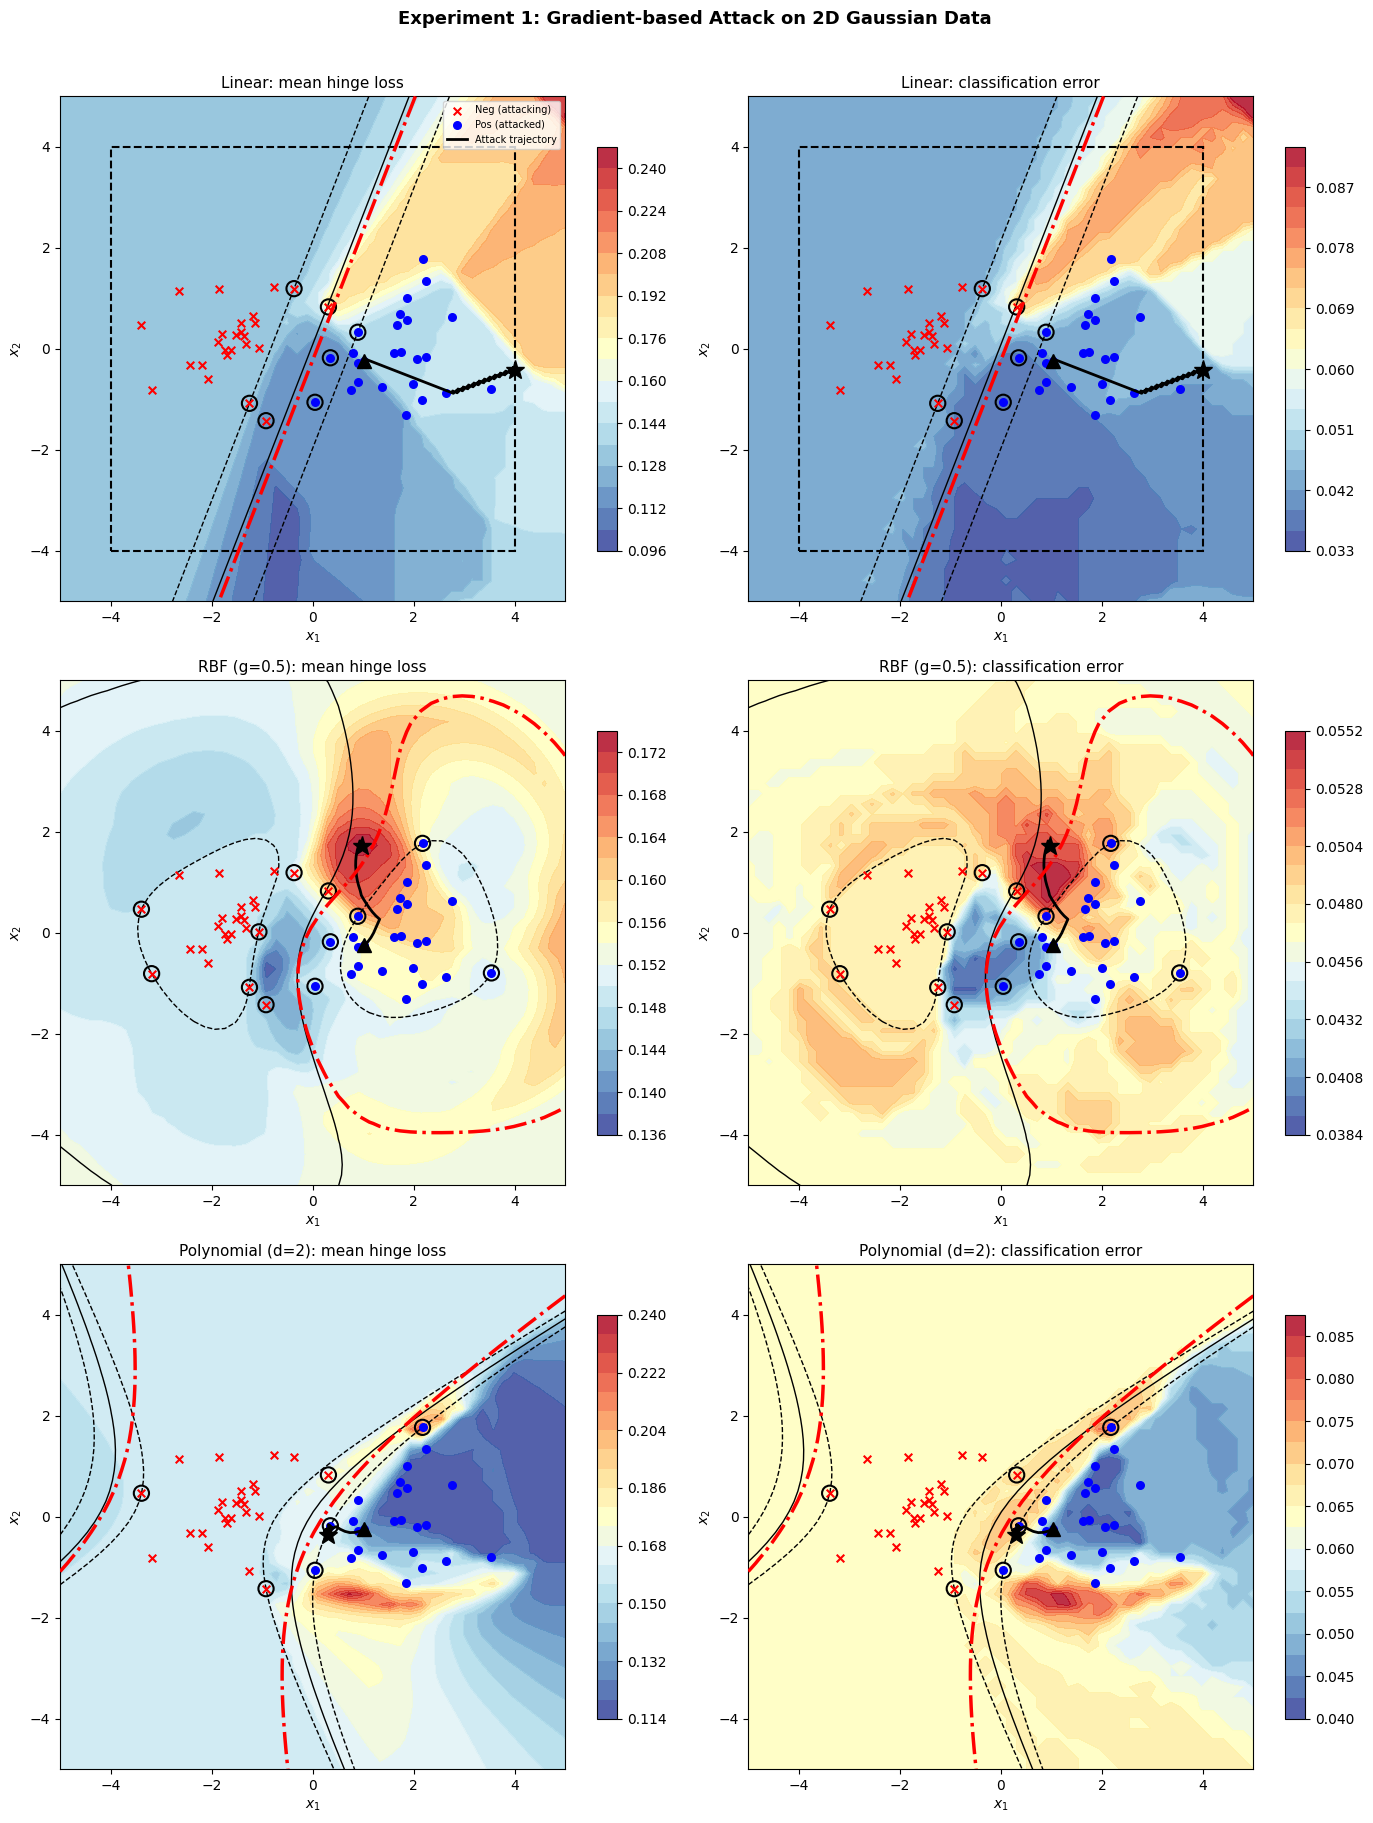


  --- EXTENSION: Multi-Point Boundary Flip ---
  Injecting 10 poison points sequentially...
  Final:      hinge_loss=153.97 (best: 187.47), val_err=0.0580
  Final:      hinge_loss=187.67 (best: 188.57), val_err=0.0720
  Final:      hinge_loss=200.48 (best: 200.62), val_err=0.0560
  Final:      hinge_loss=230.93 (best: 234.08), val_err=0.0800
  Final:      hinge_loss=222.80 (best: 225.57), val_err=0.0710
  Final:      hinge_loss=225.42 (best: 228.84), val_err=0.0740
  Final:      hinge_loss=254.86 (best: 254.98), val_err=0.0840
  Final:      hinge_loss=274.41 (best: 275.98), val_err=0.0960
  Final:      hinge_loss=296.61 (best: 296.71), val_err=0.0960
  Final:      hinge_loss=365.93 (best: 366.05), val_err=0.1350
  Figure saved: experiment_1_multipoint_flip.png


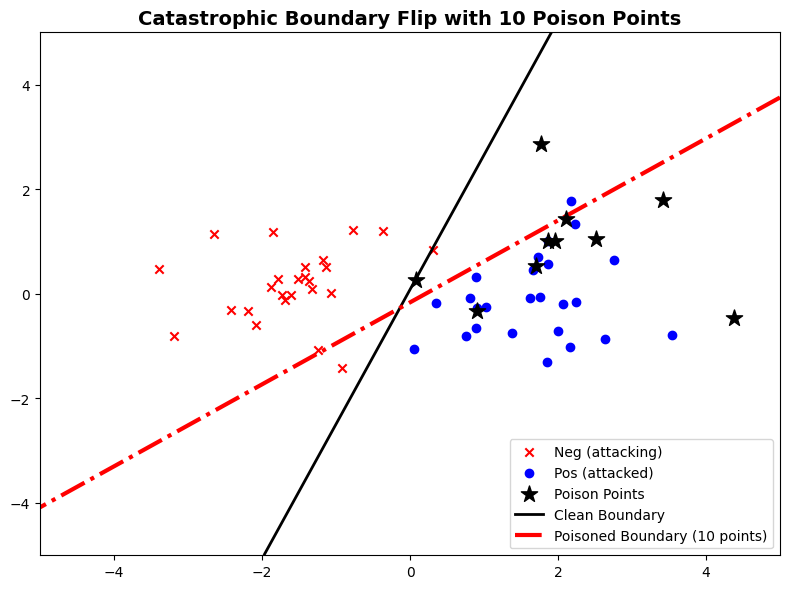

In [38]:
run_experiment_1(per_kernel_sign=per_kernel_sign)



## SECTION 12: RUN EXPERIMENT 2


Loading MNIST dataset (this may take a moment on first run)...

EXPERIMENT 2: MNIST Single-Point Attack (Paper Fig. 2)

--- 7 vs 1 ---
  Train: 100, Val: 500, Test: 2163
  Initial point: training sample 21 (digit '7' with label flipped to '1')
  Iter    0: hinge_loss=49.58, val_err=0.0180, test_err=0.0208
  Iter   50: hinge_loss=210.11, val_err=0.1540, test_err=0.1382
  Iter  100: hinge_loss=181.12, val_err=0.1360, test_err=0.1156
  Iter  150: hinge_loss=162.41, val_err=0.1240, test_err=0.0962
  Converged at iteration 169 (Delta L = 0.004819)
  Final:      hinge_loss=157.41 (best: 226.64), val_err=0.1200, test_err=0.0925

--- 9 vs 8 ---
  Train: 100, Val: 500, Test: 1983
  Initial point: training sample 41 (digit '9' with label flipped to '8')
  Iter    0: hinge_loss=92.40, val_err=0.0440, test_err=0.0368
  Iter   50: hinge_loss=252.26, val_err=0.2000, test_err=0.1704
  Converged at iteration 66 (Delta L = 0.000542)
  Final:      hinge_loss=236.25 (best: 257.39), val_err=0.1860, test_e

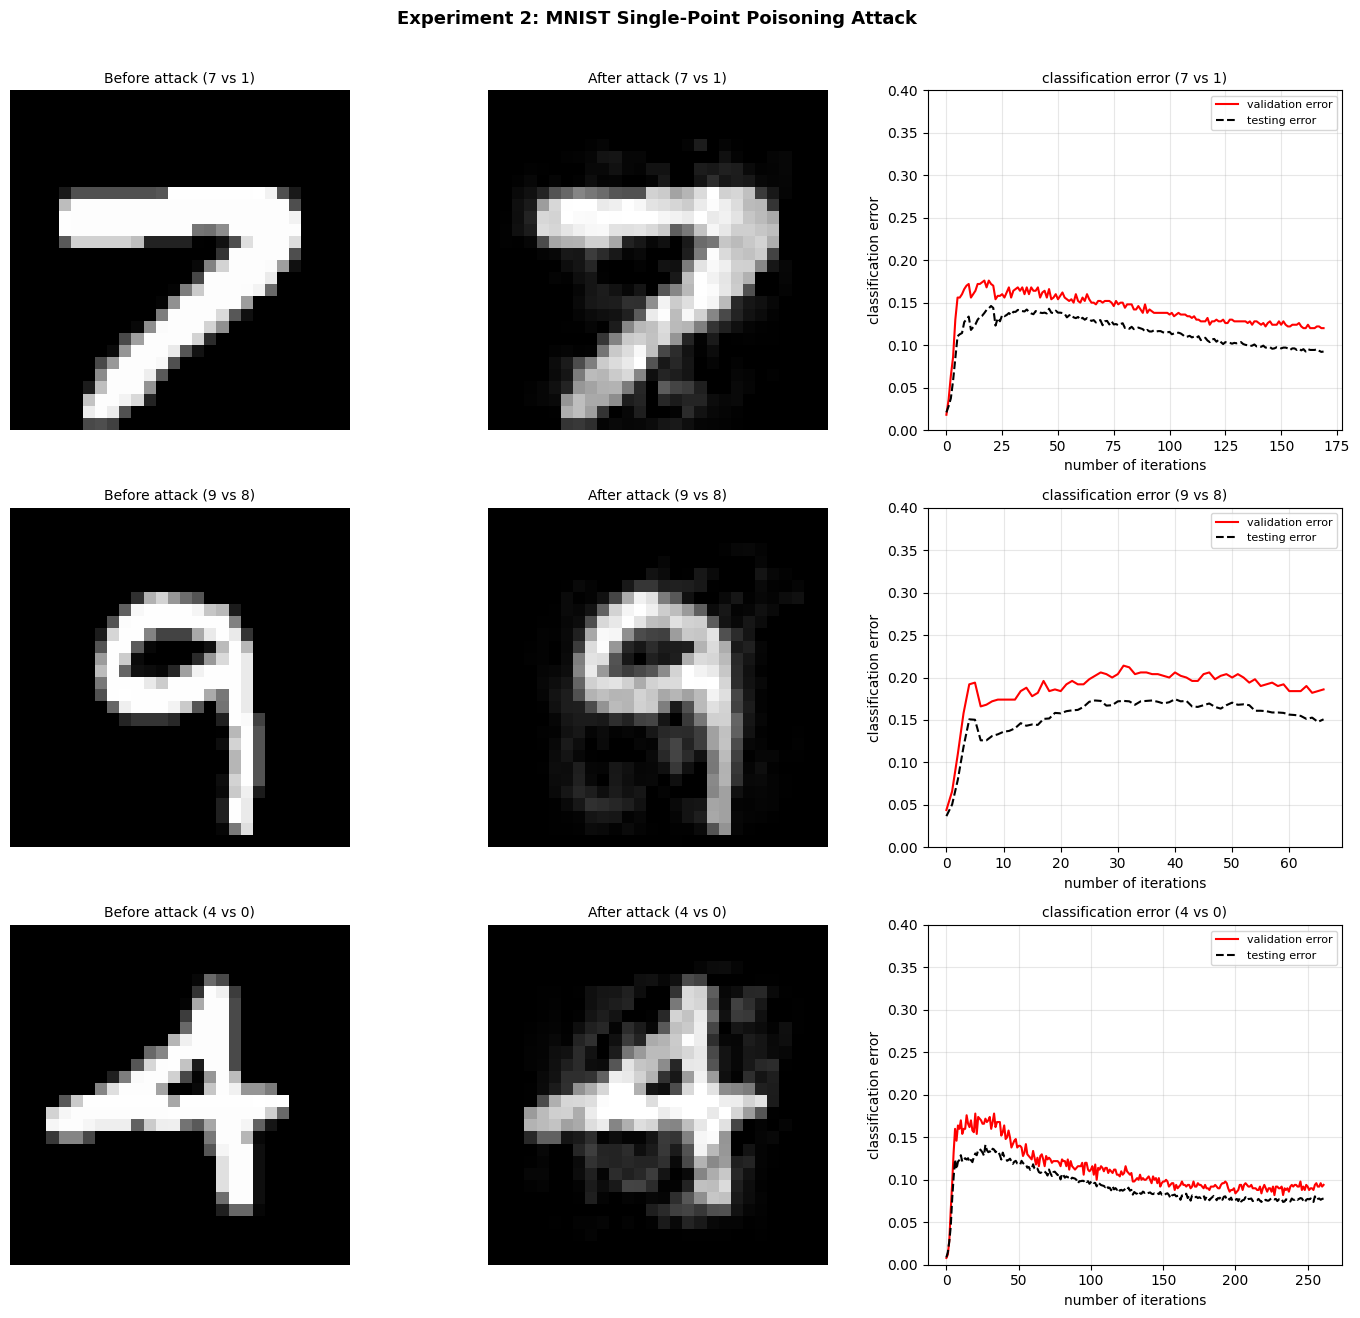

In [39]:
X_mnist, y_mnist = load_mnist()
run_experiment_2(X_mnist, y_mnist)



## SECTION 13: RUN EXPERIMENT 3



EXPERIMENT 3: MNIST Multi-Point Attack (Paper Fig. 3)

--- Multi-Point: 7 vs 1 ---
  Run 1/3
    1 pts: val_err=0.1680, test_err=0.1438
    2 pts: val_err=0.2400, test_err=0.1822
    3 pts: val_err=0.2720, test_err=0.2136
    4 pts: val_err=0.2840, test_err=0.2288
    5 pts: val_err=0.3200, test_err=0.2455
    6 pts: val_err=0.3060, test_err=0.2450
    7 pts: val_err=0.3160, test_err=0.2478
    8 pts: val_err=0.3320, test_err=0.2848
  Run 2/3
    1 pts: val_err=0.1760, test_err=0.1475
    2 pts: val_err=0.2280, test_err=0.1974
    3 pts: val_err=0.2560, test_err=0.2053
    4 pts: val_err=0.2500, test_err=0.2030
    5 pts: val_err=0.2680, test_err=0.2085
    6 pts: val_err=0.2680, test_err=0.2150
    7 pts: val_err=0.2680, test_err=0.2117
    8 pts: val_err=0.2600, test_err=0.2145
  Run 3/3
    1 pts: val_err=0.1920, test_err=0.1355
    2 pts: val_err=0.2420, test_err=0.1637
    3 pts: val_err=0.2760, test_err=0.1960
    4 pts: val_err=0.2740, test_err=0.2113
    5 pts: val_err=0.2780,

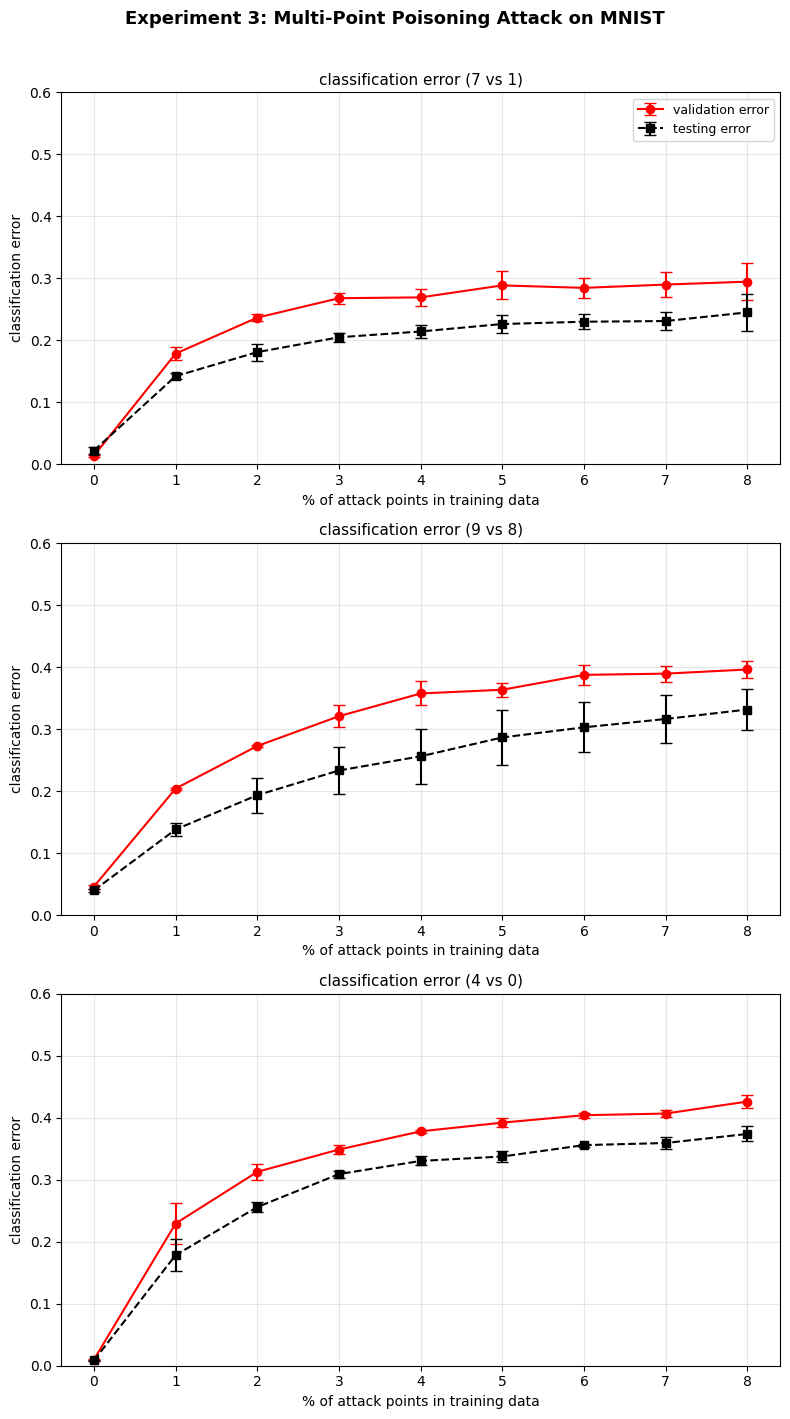

In [40]:
run_experiment_3(X_mnist, y_mnist)



## SECTION 14: SUMMARY


In [41]:
elapsed = time.time() - start_time
print("\n" + "=" * 60)
print(f"All experiments completed in {elapsed:.1f} seconds.")
print("=" * 60)



All experiments completed in 185.8 seconds.
